<a href="https://colab.research.google.com/github/AlexMoffatt10/COM7019/blob/main/COM7019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import os
import warnings
import json

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [30]:
#Reproducibility
tf.random.set_seed(42)
np.random.seed(42)


In [31]:

#OUTPUT DIRECTORY
OUT_DIR = 'outputs'
os.makedirs(OUT_DIR, exist_ok=True)

CSV_PATH = 'Stock_Price_Data_[3921].csv'


In [32]:
#DATA LOADING AND EXPLORATION


print("Loading and Exploring Data")


df = pd.read_csv(CSV_PATH, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()}  to  {df['Date'].max().date()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nBasic statistics:")
print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(4))
print(f"\nMissing values: {df.isnull().sum().to_dict()}")


df_model = df[df['Date'] >= '2010-01-01'].reset_index(drop=True)
print(f"\nModelling subset: {len(df_model)} rows ({df_model['Date'].min().date()} to {df_model['Date'].max().date()})")

Loading and Exploring Data

Dataset shape: (9909, 7)
Date range: 1980-12-12  to  2020-04-01

First 5 rows:
        Date      Open      High       Low     Close  Adj Close     Volume
0 1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400
1 1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200
2 1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000
3 1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400
4 1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400

Basic statistics:
            Open       High        Low      Close        Volume
count  9909.0000  9909.0000  9909.0000  9909.0000  9.909000e+03
mean     32.6068    32.9361    32.2776    32.6180  8.582916e+07
std      58.4158    59.0016    57.8830    58.4719  8.597195e+07
min       0.1987     0.1987     0.1964     0.1964  3.472000e+05
25%       1.0714     1.0893     1.0486     1.0714  3.304230e+07
50%       1.7293     1.7589     1.6964  

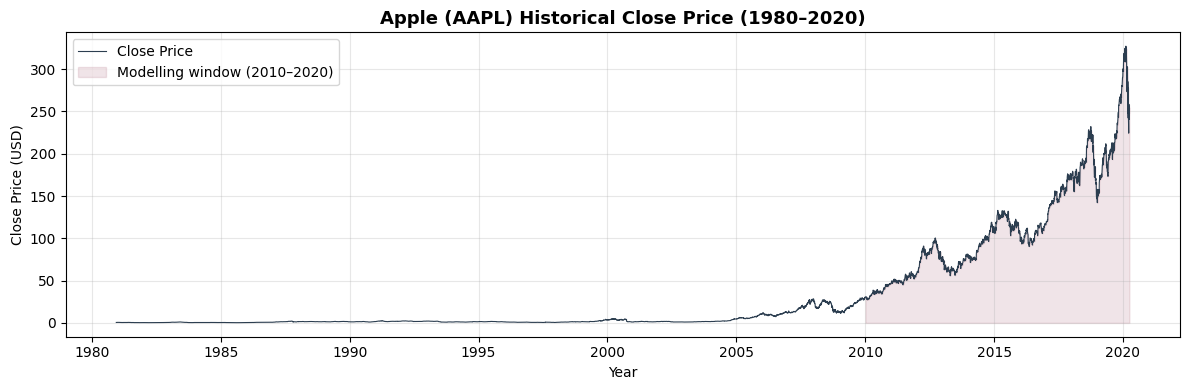

In [33]:
#Figure 1: Full historical price
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['Date'], df['Close'], color='#2C3E50', linewidth=0.8, label='Close Price')
ax.fill_between(df_model['Date'], df_model['Close'], alpha=0.12,
                color='#8B2942', label='Modelling window (2010–2020)')
ax.set_title('Apple (AAPL) Historical Close Price (1980–2020)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Close Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig1_price_history.png', dpi=150)
plt.show()


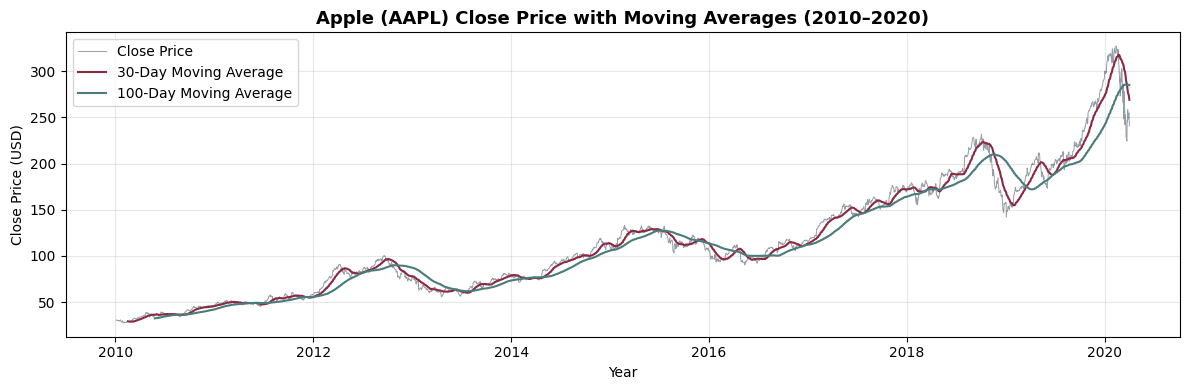

In [34]:
#Figure 2: Moving Average Trend
ma30  = df_model['Close'].rolling(window=30).mean()
ma100 = df_model['Close'].rolling(window=100).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_model['Date'], df_model['Close'], color='#2C3E50',
        linewidth=0.7, alpha=0.5, label='Close Price')
ax.plot(df_model['Date'], ma30,  color='#8B2942',
        linewidth=1.5, label='30-Day Moving Average')
ax.plot(df_model['Date'], ma100, color='#4A7C7C',
        linewidth=1.5, label='100-Day Moving Average')
ax.set_title('Apple (AAPL) Close Price with Moving Averages (2010–2020)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Close Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig2_moving_average.png', dpi=150)
plt.show()


In [35]:
 #DATA PREPROCESSING

print("SECTION 2: Preprocessing")



close_prices = df_model['Close'].values.reshape(-1, 1)


scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(close_prices)
print(f"Price range before scaling: [{close_prices.min():.2f}, {close_prices.max():.2f}]")
print(f"Price range after  scaling: [{scaled_prices.min():.4f}, {scaled_prices.max():.4f}]")


WINDOW_SIZE = 60
TRAIN_RATIO = 0.80

def create_sequences(data, window):

    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_prices, WINDOW_SIZE)
split_idx = int(len(X) * TRAIN_RATIO)

X_train = X[:split_idx].reshape(-1, WINDOW_SIZE, 1)
X_test  = X[split_idx:].reshape(-1, WINDOW_SIZE, 1)
y_train = y[:split_idx]
y_test  = y[split_idx:]

print(f"\nSequence window: {WINDOW_SIZE} timesteps")
print(f"X_train shape: {X_train.shape}  |  y_train shape: {y_train.shape}")
print(f"X_test  shape: {X_test.shape}   |  y_test  shape: {y_test.shape}")

SECTION 2: Preprocessing
Price range before scaling: [27.44, 327.20]
Price range after  scaling: [0.0000, 1.0000]

Sequence window: 60 timesteps
X_train shape: (2015, 60, 1)  |  y_train shape: (2015,)
X_test  shape: (504, 60, 1)   |  y_test  shape: (504,)


In [36]:
 #MODEL 1 - LSTM


print("Building and Training LSTM Model")


def build_lstm_model(window_size):

    model = Sequential(name='LSTM_Model')
    model.add(LSTM(64, return_sequences=True, input_shape=(window_size, 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(32, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

lstm_model = build_lstm_model(WINDOW_SIZE)
lstm_model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

print("\nTraining LSTM...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.10,
    callbacks=[early_stop],
    verbose=1
)
lstm_epochs_run = len(lstm_history.history['loss'])
print(f"\nLSTM early-stopped at epoch {lstm_epochs_run}")

Building and Training LSTM Model


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - loss: 0.0045 - val_loss: 0.0027
Epoch 2/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 7.5034e-04 - val_loss: 5.7479e-04
Epoch 3/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 5.5509e-04 - val_loss: 6.6144e-04
Epoch 4/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 5.0915e-04 - val_loss: 4.8480e-04
Epoch 5/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 4.0164e-04 - val_loss: 4.1176e-04
Epoch 6/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 4.2246e-04 - val_loss: 5.9087e-04
Epoch 7/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 3.7407e-04 - val_loss: 4.3268e-04
Epoch 8/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 3.2257e-04 - val_loss: 4.0007e-04
Epoch 9/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 3.2742e-04 - val_loss: 3.2852e-04
Epoch 10/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 2.8280e-04 - val_loss: 5.4088e-04
Epoch 11/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss:

In [37]:
#MODEL 2 - GRU

print("Building and Training GRU Model")

def build_gru_model(window_size):

    model = Sequential(name='GRU_Model')
    model.add(GRU(64, return_sequences=True, input_shape=(window_size, 1)))
    model.add(Dropout(0.2))
    model.add(GRU(32, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

gru_model = build_gru_model(WINDOW_SIZE)
gru_model.summary()


early_stop_gru = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

print("\nTraining GRU...")
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.10,
    callbacks=[early_stop_gru],
    verbose=1
)
gru_epochs_run = len(gru_history.history['loss'])
print(f"\nGRU early-stopped at epoch {gru_epochs_run}")



Building and Training GRU Model


Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,817 (89.13 KB)

 Trainable params: 22,817 (89.13 KB)

 Non-trainable params: 0 (0.00 B)


Training GRU...
Epoch 1/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - loss: 0.0037 - val_loss: 1.8552e-04
Epoch 2/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 6.1611e-04 - val_loss: 3.0499e-04
Epoch 3/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 4.6203e-04 - val_loss: 7.6759e-04
Epoch 4/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 4.3969e-04 - val_loss: 3.5605e-04
Epoch 5/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 3.4961e-04 - val_loss: 3.9669e-04
Epoch 6/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 3.1545e-04 - val_loss: 3.7399e-04
Epoch 7/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 2.6060e-04 - val_loss: 4.9454e-04
Epoch 8/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 2.6051e-04 - val_loss: 6.4372e-04
Epoch 9/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 2.2706e-04 - val_loss: 1.6877e-04
Epoch 10/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 2.0515e-04 - val_loss: 1.4728e-04
Epoch 11/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - lo

In [38]:
#PREDICTIONS AND EVALUATION


print("Generating Predictions and Evaluating Performance")



lstm_pred = scaler.inverse_transform(
    lstm_model.predict(X_test, verbose=0).reshape(-1, 1)
).flatten()
gru_pred = scaler.inverse_transform(
    gru_model.predict(X_test, verbose=0).reshape(-1, 1)
).flatten()
actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


def compute_metrics(true, pred, model_name):
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2   = r2_score(true, pred)
    mape = np.mean(np.abs((true - pred) / true)) * 100
    print(f"\n{'─'*40}")
    print(f"  {model_name} Performance Metrics")
    print(f"{'─'*40}")
    print(f"  MAE  (Mean Absolute Error):      {mae:.4f} USD")
    print(f"  RMSE (Root Mean Squared Error):  {rmse:.4f} USD")
    print(f"  R²   (Coefficient of Det.):      {r2:.4f}")
    print(f"  MAPE (Mean Abs. Pct. Error):     {mape:.2f}%")
    return {'MAE': round(mae, 4), 'RMSE': round(rmse, 4),
            'R2': round(r2, 4), 'MAPE': round(mape, 2)}

lstm_metrics = compute_metrics(actual, lstm_pred, "LSTM")
gru_metrics  = compute_metrics(actual, gru_pred,  "GRU")

Generating Predictions and Evaluating Performance

────────────────────────────────────────
  LSTM Performance Metrics
────────────────────────────────────────
  MAE  (Mean Absolute Error):      5.9677 USD
  RMSE (Root Mean Squared Error):  9.0190 USD
  R²   (Coefficient of Det.):      0.9549
  MAPE (Mean Abs. Pct. Error):     2.82%

────────────────────────────────────────
  GRU Performance Metrics
────────────────────────────────────────
  MAE  (Mean Absolute Error):      4.0126 USD
  RMSE (Root Mean Squared Error):  5.5256 USD
  R²   (Coefficient of Det.):      0.9831
  MAPE (Mean Abs. Pct. Error):     1.83%


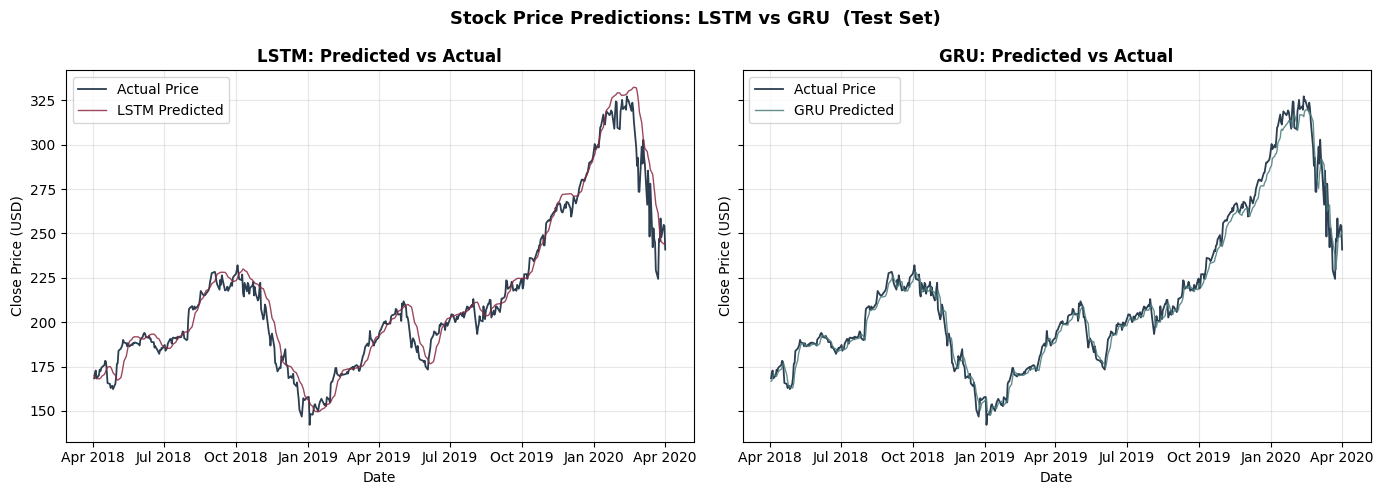

In [39]:
#Predicted vs Actual
test_dates = df_model['Date'].values[WINDOW_SIZE + split_idx:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, pred, name, col in zip(
        axes,
        [lstm_pred, gru_pred],
        ['LSTM', 'GRU'],
        ['#8B2942', '#4A7C7C']):
    ax.plot(test_dates, actual, label='Actual Price',
            color='#2C3E50', linewidth=1.3)
    ax.plot(test_dates, pred, label=f'{name} Predicted',
            color=col, linewidth=1.0, alpha=0.85)
    ax.set_title(f'{name}: Predicted vs Actual', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Stock Price Predictions: LSTM vs GRU  (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig3_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


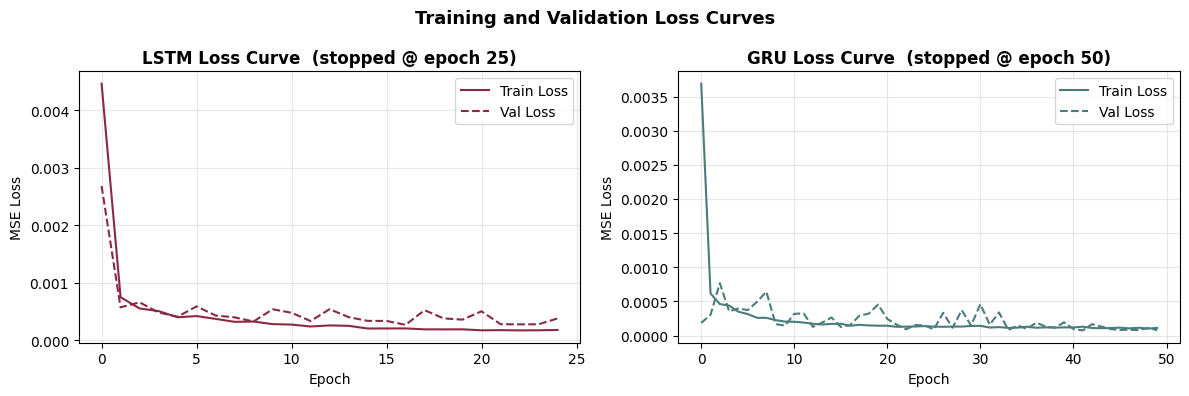

In [40]:
#Training / Validation Loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, name, col in zip(
        axes,
        [lstm_history, gru_history],
        ['LSTM', 'GRU'],
        ['#8B2942', '#4A7C7C']):
    ax.plot(hist.history['loss'], label='Train Loss',
            color=col, linewidth=1.5)
    ax.plot(hist.history['val_loss'], label='Val Loss',
            color=col, linewidth=1.5, linestyle='--')
    stopped = len(hist.history['loss'])
    ax.set_title(f'{name} Loss Curve  (stopped @ epoch {stopped})',
                 fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training and Validation Loss Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig4_loss_curves.png', dpi=150)
plt.show()


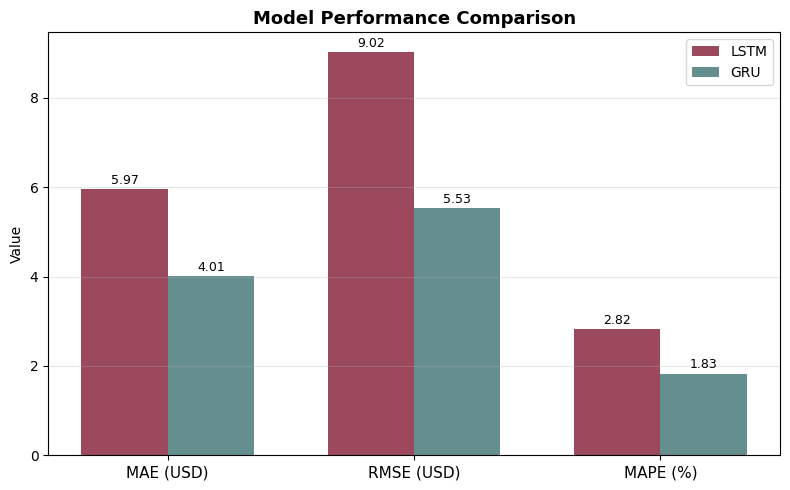

In [41]:
#Metrics Bar Chart
metric_labels = ['MAE (USD)', 'RMSE (USD)', 'MAPE (%)']
lstm_vals = [lstm_metrics['MAE'], lstm_metrics['RMSE'], lstm_metrics['MAPE']]
gru_vals  = [gru_metrics['MAE'],  gru_metrics['RMSE'],  gru_metrics['MAPE']]

x = np.arange(len(metric_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, lstm_vals, w, label='LSTM', color='#8B2942', alpha=0.85)
bars2 = ax.bar(x + w/2, gru_vals,  w, label='GRU',  color='#4A7C7C', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel('Value')
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig5_metrics_comparison.png', dpi=150)
plt.show()







In [42]:
# ── R² comparison

print("Summary Comparison")

print(f"\n{'Metric':<12} {'LSTM':>10} {'GRU':>10} {'Better':>10}")
print("─" * 44)
for m in ['MAE', 'RMSE', 'MAPE']:
    better = 'GRU' if gru_metrics[m] < lstm_metrics[m] else 'LSTM'
    print(f"{m:<12} {lstm_metrics[m]:>10} {gru_metrics[m]:>10} {better:>10}")
better_r2 = 'GRU' if gru_metrics['R2'] > lstm_metrics['R2'] else 'LSTM'
print(f"{'R2 (higher)':<12} {lstm_metrics['R2']:>10} {gru_metrics['R2']:>10} {better_r2:>10}")

winner = 'GRU' if gru_metrics['RMSE'] < lstm_metrics['RMSE'] else 'LSTM'
print(f"\n Recommended model: {winner} ")


results = {
    'lstm': lstm_metrics,
    'gru': gru_metrics,
    'lstm_epochs': lstm_epochs_run,
    'gru_epochs': gru_epochs_run,
    'window_size': WINDOW_SIZE,
    'train_ratio': TRAIN_RATIO
}
with open(f'{OUT_DIR}/model_results.json', 'w') as f:
    json.dump(results, f, indent=2)

Summary Comparison

Metric             LSTM        GRU     Better
────────────────────────────────────────────
MAE              5.9677     4.0126        GRU
RMSE              9.019     5.5256        GRU
MAPE               2.82       1.83        GRU
R2 (higher)      0.9549     0.9831        GRU

 Recommended model: GRU 
